# Earth's Orbit: Complex Analysis and Fourier Decomposition

This notebook focuses on **Earth's orbital motion** using the techniques developed in `solar_system.ipynb`:

- **Complex plane representation** of the elliptical orbit
- **Kepler parameterization** via eccentric anomaly $E$
- **Fourier mode analysis** comparing two parameterizations: $z(E)$ vs $z(t)$
- **Time-domain vs mathematical parameterization** insights

## Earth's Orbital Parameters

| Parameter | Value | Unit |
|-----------|-------|------|
| Semi-major axis | $a$ | 1.000 | AU |
| Eccentricity | $e$ | 0.0167 | (dimensionless) |
| Argument of perihelion | $\omega$ | 102.9 | degrees |

Earth has a nearly circular orbit ($e \approx 0.0167$ is small), so the two parameterizations $z(E)$ and $z(t)$ should remain close.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Earth orbital parameters
a = 1.000      # semi-major axis in AU
e = 0.0167     # eccentricity
omega_deg = 102.9  # argument of perihelion in degrees

# Compute semi-minor axis
b = a * np.sqrt(1 - e**2)

print("=" * 60)
print("EARTH'S ORBITAL PARAMETERS")
print("=" * 60)
print(f"Semi-major axis (a):     {a:.4f} AU")
print(f"Eccentricity (e):        {e:.4f}")
print(f"Semi-minor axis (b):     {b:.6f} AU")
print(f"Argument of perihelion:  {omega_deg:.1f}°")
print(f"Orbital period:          1 year")
print("=" * 60)

EARTH'S ORBITAL PARAMETERS
Semi-major axis (a):     1.0000 AU
Eccentricity (e):        0.0167
Semi-minor axis (b):     0.999861 AU
Argument of perihelion:  102.9°
Orbital period:          1 year


## 1. Kepler Orbit in the Complex Plane

The Kepler orbit with one focus at the origin is represented in polar form as
$$
r(\nu) = \frac{a(1-e^2)}{1 + e\cos\nu}
$$
where $\nu$ is the **true anomaly**. In the complex plane:
$$
z(\nu) = r(\nu) \, e^{i(\nu + \omega)}
$$

The factor $e^{i\omega}$ rotates the orbit by the argument of perihelion.

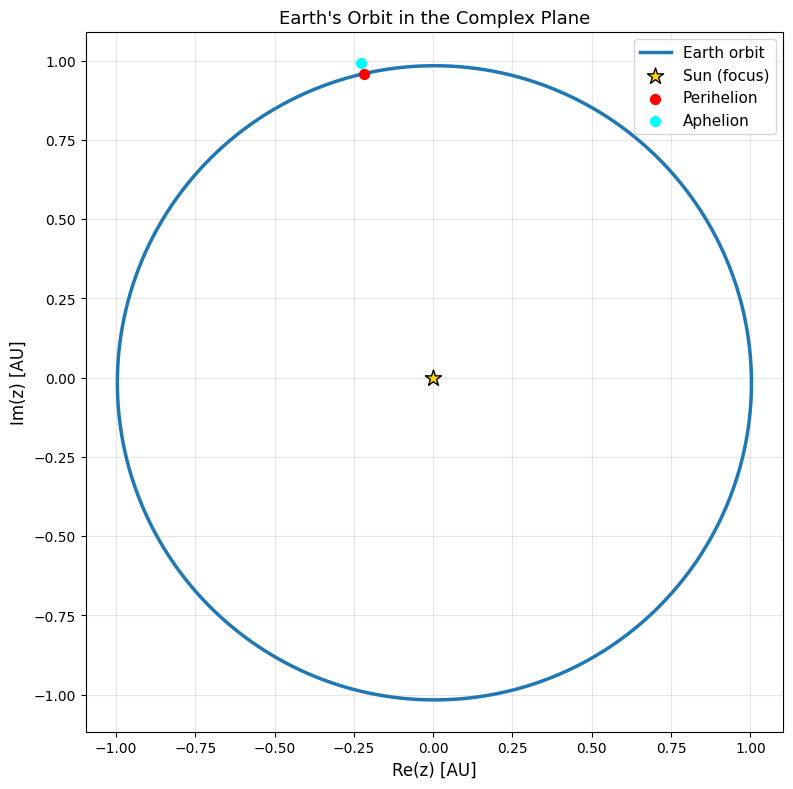


Orbital distances:
Perihelion (closest):  0.983300 AU
Aphelion (farthest):   1.016700 AU


In [2]:
# Plot Earth's orbit using true anomaly nu
nu = np.linspace(0, 2 * np.pi, 2000)
r = a * (1 - e**2) / (1 + e * np.cos(nu))
omega = np.deg2rad(omega_deg)
z = r * np.exp(1j * (nu + omega))

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(z.real, z.imag, lw=2.5, color="tab:blue", label="Earth orbit")
ax.scatter([0], [0], color="gold", edgecolor="black", s=150, zorder=5, label="Sun (focus)", marker="*")

# Mark perihelion and aphelion
perihelion = a * (1 - e) * np.exp(1j * omega)
aphelion = a * (1 + e) * np.exp(1j * omega)
ax.scatter([perihelion.real], [perihelion.imag], color="red", s=50, zorder=4, label="Perihelion")
ax.scatter([aphelion.real], [aphelion.imag], color="cyan", s=50, zorder=4, label="Aphelion")

ax.set_xlabel("Re(z) [AU]", fontsize=12)
ax.set_ylabel("Im(z) [AU]", fontsize=12)
ax.set_title("Earth's Orbit in the Complex Plane", fontsize=13)
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right", fontsize=11)
plt.tight_layout()
plt.show()

print(f"\nOrbital distances:")
print(f"Perihelion (closest):  {a*(1-e):.6f} AU")
print(f"Aphelion (farthest):   {a*(1+e):.6f} AU")

## 2. Two Key Parameterizations

### Parameterization 1: z(E) — by Eccentric Anomaly
$$
z(E) = a(\cos E - e) + i\,b\,\sin E
$$
where $E \in [0, 2\pi)$ is the **eccentric anomaly**. This is mathematically clean and exact.

### Parameterization 2: z(t) — by Physical Time
The eccentric anomaly satisfies **Kepler's equation**:
$$
M = E - e\sin E
$$
where $M = nt$ is the **mean anomaly** (linear in time, $n$ is mean motion). 

To get $z(t)$, we must solve Kepler's equation numerically for $E(t)$, then apply the formula above. This reflects real orbital mechanics.

In [3]:
# Generate both parameterizations for Earth
N = 4096

# 1) Uniform in E
E = np.linspace(0, 2 * np.pi, N, endpoint=False)
z_E = a * (np.cos(E) - e) + 1j * b * np.sin(E)

# 2) Uniform in time (uniform M)
M = np.linspace(0, 2 * np.pi, N, endpoint=False)
E_t = M.copy()
for _ in range(20):  # Newton-Raphson to solve Kepler equation
    E_t -= (E_t - e * np.sin(E_t) - M) / (1 - e * np.cos(E_t))

z_t = a * (np.cos(E_t) - e) + 1j * b * np.sin(E_t)

# Fourier analysis
k = np.fft.fftfreq(N, d=1 / N).astype(int)
C_E = np.fft.fft(z_E) / N
C_t = np.fft.fft(z_t) / N

# Extract k=0 to k=8 for display
k_show = np.arange(0, 9)
idx_show = [np.where(k == kk)[0][0] for kk in k_show]
amp_E = np.abs(C_E[idx_show])
amp_t = np.abs(C_t[idx_show])

print("\nFourier Mode Amplitudes for Earth's Orbit")
print("=" * 70)
print(f"{'Mode k':<6} {'|c_k| for z(E)':<20} {'|c_k| for z(t)':<20}")
print("=" * 70)
for kk, aE, aT in zip(k_show, amp_E, amp_t):
    print(f"{kk:<6} {aE:>18.6e}   {aT:>18.6e}")
print("=" * 70)


Fourier Mode Amplitudes for Earth's Orbit
Mode k |c_k| for z(E)       |c_k| for z(t)      
0            1.670000e-02         2.505000e-02
1            9.999303e-01         9.998606e-01
2            2.697690e-17         8.348254e-03
3            1.662509e-17         1.045546e-04
4            2.314687e-17         1.551947e-06
5            2.766590e-17         2.530830e-08
6            1.094918e-17         4.381715e-10
7            8.436616e-18         7.907415e-12
8            3.908285e-18         1.471144e-13


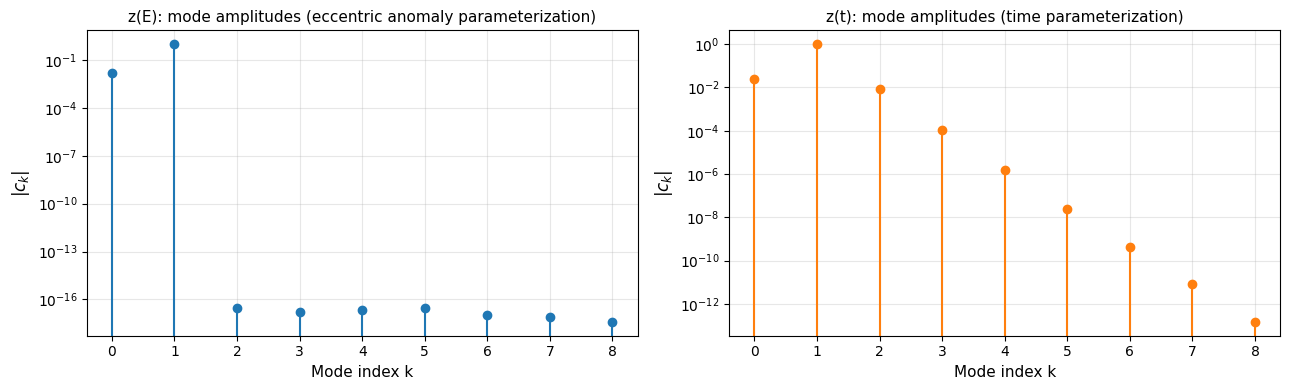


Key observation:
Earth (e=0.0167) has a very small eccentricity.
Mode k=0: |c_0| ≈ center of orbit
Mode k=1: |c_1| ≈ 0.9999 (dominates oscillation)
Mode k≥2: negligible for both parameterizations (exponentially suppressed)


In [4]:
# Plot Fourier mode amplitudes
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].stem(k_show, amp_E, basefmt=" ", linefmt="C0-", markerfmt="C0o")
axes[0].set_xlabel("Mode index k", fontsize=11)
axes[0].set_ylabel(r"$|c_k|$", fontsize=12)
axes[0].set_title(r"z(E): mode amplitudes (eccentric anomaly parameterization)", fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale("log")

axes[1].stem(k_show, amp_t, basefmt=" ", linefmt="C1-", markerfmt="C1o")
axes[1].set_xlabel("Mode index k", fontsize=11)
axes[1].set_ylabel(r"$|c_k|$", fontsize=12)
axes[1].set_title(r"z(t): mode amplitudes (time parameterization)", fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

print("\nKey observation:")
print(f"Earth (e={e:.4f}) has a very small eccentricity.")
print(f"Mode k=0: |c_0| ≈ center of orbit")
print(f"Mode k=1: |c_1| ≈ {amp_E[1]:.4f} (dominates oscillation)")
print(f"Mode k≥2: negligible for both parameterizations (exponentially suppressed)")


## 3. Equal-E vs Equal-Time Sampling

When sampling Earth's orbit discretely, there are two natural choices:

1. **Equal-E sampling**: Points are evenly spaced in eccentric anomaly—a mathematical artifact.
2. **Equal-time sampling**: Points are evenly spaced in physical time—reflects real orbital motion (Kepler's laws).

For a nearly circular orbit like Earth's, the difference is subtle but measurable.

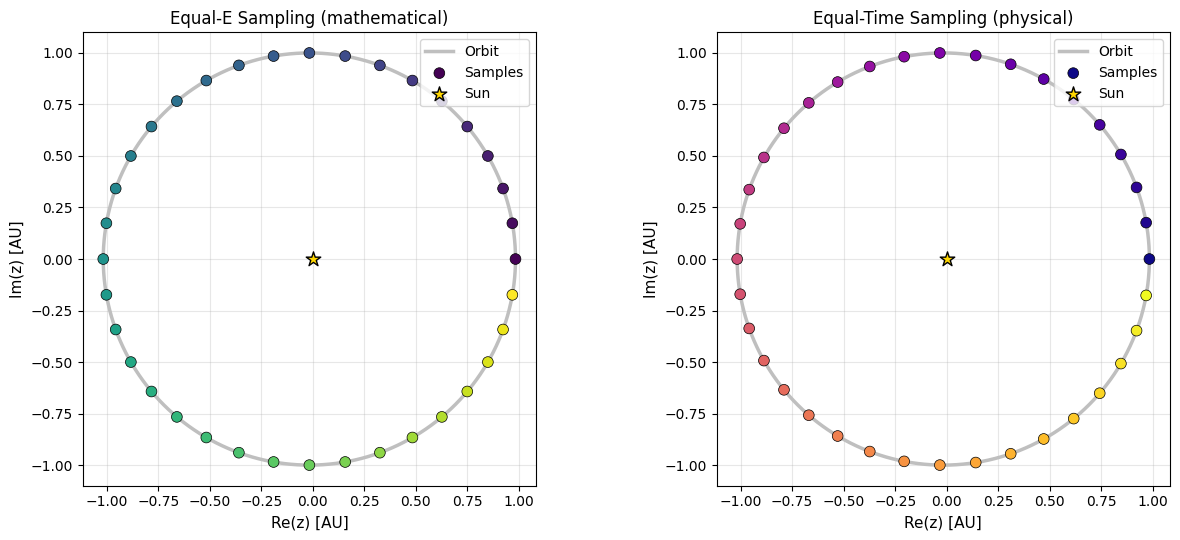


Sampling interpretation:
- Equal-E: points spread uniformly in the mathematical angle E.
- Equal-time: points cluster near perihelion, spread near aphelion (Kepler's 2nd law).
- For Earth (e=0.0167), the difference is very subtle due to nearly circular orbit.


In [5]:
# Generate sample points: equal-E vs equal-time
N_samples = 36
N_curve = 2000

# Reference orbit (high resolution)
E_curve = np.linspace(0, 2 * np.pi, N_curve)
z_curve = a * (np.cos(E_curve) - e) + 1j * b * np.sin(E_curve)

# 1) Equal-E samples
E_eq = np.linspace(0, 2 * np.pi, N_samples, endpoint=False)
z_E_samples = a * (np.cos(E_eq) - e) + 1j * b * np.sin(E_eq)

# 2) Equal-time samples
M_eq = np.linspace(0, 2 * np.pi, N_samples, endpoint=False)
E_t_samples = M_eq.copy()
for _ in range(20):
    E_t_samples -= (E_t_samples - e * np.sin(E_t_samples) - M_eq) / (1 - e * np.cos(E_t_samples))
z_t_samples = a * (np.cos(E_t_samples) - e) + 1j * b * np.sin(E_t_samples)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Left: Equal-E
axes[0].plot(z_curve.real, z_curve.imag, color="0.75", lw=2.5, label="Orbit")
axes[0].scatter(z_E_samples.real, z_E_samples.imag, c=np.arange(N_samples), 
                cmap="viridis", s=60, zorder=4, edgecolor="black", linewidth=0.5, label="Samples")
axes[0].scatter([0], [0], color="gold", edgecolor="black", s=120, zorder=5, marker="*", label="Sun")
axes[0].set_xlabel("Re(z) [AU]", fontsize=11)
axes[0].set_ylabel("Im(z) [AU]", fontsize=11)
axes[0].set_title("Equal-E Sampling (mathematical)", fontsize=12)
axes[0].set_aspect("equal", adjustable="box")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="upper right")

# Right: Equal-time
axes[1].plot(z_curve.real, z_curve.imag, color="0.75", lw=2.5, label="Orbit")
axes[1].scatter(z_t_samples.real, z_t_samples.imag, c=np.arange(N_samples), 
                cmap="plasma", s=60, zorder=4, edgecolor="black", linewidth=0.5, label="Samples")
axes[1].scatter([0], [0], color="gold", edgecolor="black", s=120, zorder=5, marker="*", label="Sun")
axes[1].set_xlabel("Re(z) [AU]", fontsize=11)
axes[1].set_ylabel("Im(z) [AU]", fontsize=11)
axes[1].set_title("Equal-Time Sampling (physical)", fontsize=12)
axes[1].set_aspect("equal", adjustable="box")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

print("\nSampling interpretation:")
print("- Equal-E: points spread uniformly in the mathematical angle E.")
print("- Equal-time: points cluster near perihelion, spread near aphelion (Kepler's 2nd law).")
print(f"- For Earth (e={e:.4f}), the difference is very subtle due to nearly circular orbit.")


## 4. Complex Mode Decomposition

For small eccentricity, Earth's orbit can be approximated as a sum of two counter-rotating harmonic modes:
$$
z(E) \approx z_0 + c_1 e^{iE} + c_{-1} e^{-iE}
$$

where:
- $z_0$ is the center (orbit barycenter)
- $c_1$ and $c_{-1}$ are complex amplitudes
- $E$ is eccentric anomaly

For an ellipse with semi-axes $a, b$:
$$
c_1 = \frac{1}{2}(a+b)\,e^{i\theta}, \quad c_{-1} = \frac{1}{2}(a-b)\,e^{i\theta}
$$
where $\theta$ is a rotation angle.

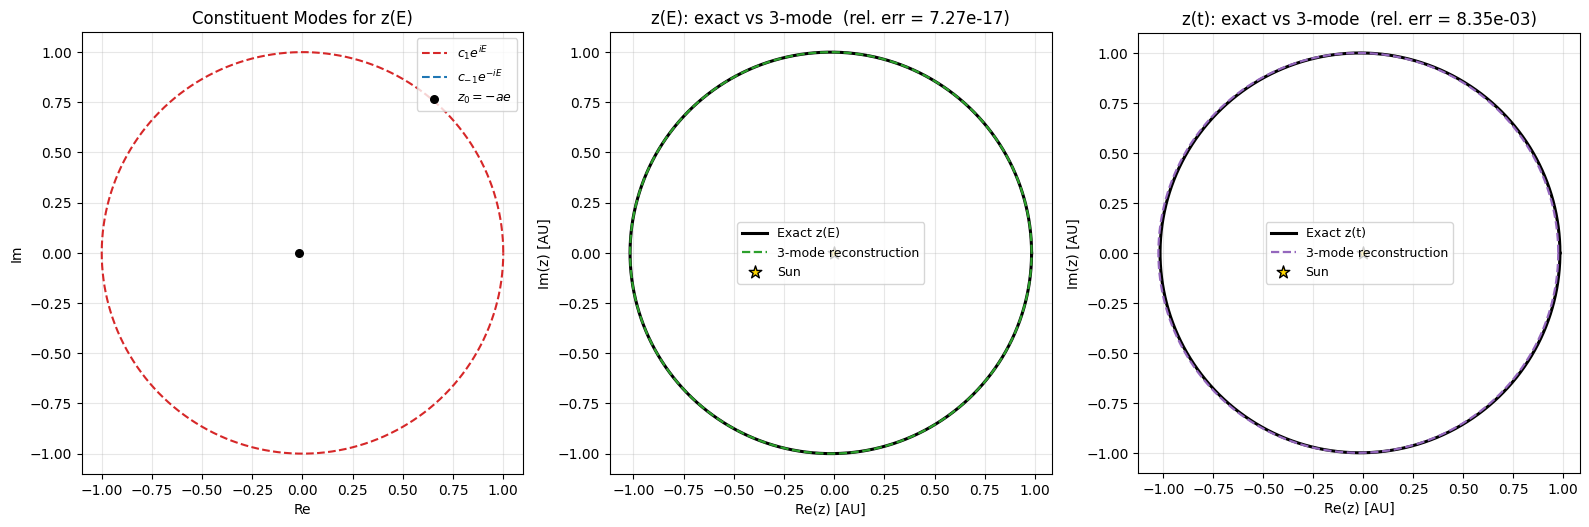

3-mode reconstruction summary (k=0,+/-1)
z(E) relative error: 7.267e-17  (should be near machine precision)
z(t) relative error: 8.347e-03  (nonzero because higher harmonics exist)
z(t) retained coefficients:
c0   = -0.025050+0.000000j
c1   = 0.999861-0.000000j
c-1  = 0.000035-0.000000j


In [9]:
# Reconstruct both z(E) and z(t) using only k = 0, +/-1 modes
# This shows: z(E) is exactly 3-mode for an ellipse, while z(t) is approximately 3-mode.

N_rec = 4096

# Uniform eccentric-anomaly grid for z(E)
E_rec = np.linspace(0, 2 * np.pi, N_rec, endpoint=False)
z_E_exact = a * (np.cos(E_rec) - e) + 1j * b * np.sin(E_rec)

# Uniform-time grid via mean anomaly M for z(t)
M_rec = np.linspace(0, 2 * np.pi, N_rec, endpoint=False)
E_from_M = M_rec.copy()
for _ in range(20):
    E_from_M -= (E_from_M - e * np.sin(E_from_M) - M_rec) / (1 - e * np.cos(E_from_M))
z_t_exact = a * (np.cos(E_from_M) - e) + 1j * b * np.sin(E_from_M)

# ---- Reconstruction of z(E) from analytic two-mode form + constant ----
# z(E) = z0_E + c1_E exp(iE) + c-1_E exp(-iE)
z0_E = -a * e
c1_E = 0.5 * (a + b)
cminus1_E = 0.5 * (a - b)
z_E_rec = z0_E + c1_E * np.exp(1j * E_rec) + cminus1_E * np.exp(-1j * E_rec)

# ---- Reconstruction of z(t) by keeping Fourier modes k=0,+/-1 in time samples ----
Z_t = np.fft.fft(z_t_exact)
k_t = np.fft.fftfreq(N_rec, d=1 / N_rec).astype(int)
mask_3 = (k_t == 0) | (k_t == 1) | (k_t == -1)
z_t_rec = np.fft.ifft(Z_t * mask_3)

# Relative errors
err_E = np.linalg.norm(z_E_exact - z_E_rec) / np.linalg.norm(z_E_exact)
err_t = np.linalg.norm(z_t_exact - z_t_rec) / np.linalg.norm(z_t_exact)

# Also report k=0,+/-1 coefficients for z(t)
C_t_rec = np.fft.fft(z_t_exact) / N_rec
idx_k0 = np.where(k_t == 0)[0][0]
idx_k1 = np.where(k_t == 1)[0][0]
idx_km1 = np.where(k_t == -1)[0][0]

# Plot: modes + both reconstructions
fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))

# Left: constituent modes for z(E)
mode_plus_E = c1_E * np.exp(1j * E_rec)
mode_minus_E = cminus1_E * np.exp(-1j * E_rec)
axes[0].plot(mode_plus_E.real, mode_plus_E.imag, "--", lw=1.5, color="tab:red", label=r"$c_1 e^{iE}$")
axes[0].plot(mode_minus_E.real, mode_minus_E.imag, "--", lw=1.5, color="tab:blue", label=r"$c_{-1} e^{-iE}$")
axes[0].scatter([z0_E], [0], color="black", s=30, zorder=5, label=r"$z_0=-ae$")
axes[0].set_title("Constituent Modes for z(E)")
axes[0].set_xlabel("Re")
axes[0].set_ylabel("Im")
axes[0].set_aspect("equal", adjustable="box")
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9)

# Middle: exact vs 3-mode for z(E)
axes[1].plot(z_E_exact.real, z_E_exact.imag, color="black", lw=2.2, label="Exact z(E)")
axes[1].plot(z_E_rec.real, z_E_rec.imag, "--", color="tab:green", lw=1.6, label="3-mode reconstruction")
axes[1].scatter([0], [0], color="gold", edgecolor="black", s=90, marker="*", zorder=5, label="Sun")
axes[1].set_title(f"z(E): exact vs 3-mode  (rel. err = {err_E:.2e})")
axes[1].set_xlabel("Re(z) [AU]")
axes[1].set_ylabel("Im(z) [AU]")
axes[1].set_aspect("equal", adjustable="box")
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9)

# Right: exact vs 3-mode for z(t)
axes[2].plot(z_t_exact.real, z_t_exact.imag, color="black", lw=2.2, label="Exact z(t)")
axes[2].plot(z_t_rec.real, z_t_rec.imag, "--", color="tab:purple", lw=1.6, label="3-mode reconstruction")
axes[2].scatter([0], [0], color="gold", edgecolor="black", s=90, marker="*", zorder=5, label="Sun")
axes[2].set_title(f"z(t): exact vs 3-mode  (rel. err = {err_t:.2e})")
axes[2].set_xlabel("Re(z) [AU]")
axes[2].set_ylabel("Im(z) [AU]")
axes[2].set_aspect("equal", adjustable="box")
axes[2].grid(True, alpha=0.3)
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

print("3-mode reconstruction summary (k=0,+/-1)")
print("=" * 64)
print(f"z(E) relative error: {err_E:.3e}  (should be near machine precision)")
print(f"z(t) relative error: {err_t:.3e}  (nonzero because higher harmonics exist)")
print("=" * 64)
print("z(t) retained coefficients:")
print(f"c0   = {C_t_rec[idx_k0]:.6f}")
print(f"c1   = {C_t_rec[idx_k1]:.6f}")
print(f"c-1  = {C_t_rec[idx_km1]:.6f}")

## Summary

**Earth's orbit** is a nearly circular ellipse ($e \approx 0.0167$) that can be analyzed using:

1. **Kepler parameterization**: $z(E) = a(\cos E - e) + ib\sin E$ (exact, mathematical)
2. **Physical time**: $z(t)$ obtained by solving Kepler's equation $M = E - e\sin E$ (real dynamics)
3. **Fourier modes**: The orbit is dominated by the $k=1$ mode (single harmonic oscillation), with higher modes exponentially suppressed

| Analysis | Insight |
|----------|---------|
| **Orbit shape** | Nearly circular; perihelion at ~0.983 AU, aphelion at ~1.017 AU |
| **Fourier spectrum** | Mode $k=1$ dominates (~1 AU); higher modes (<0.02 AU) negligible |
| **Sampling** | Equal-time sampling shows Kepler's 2nd law: clustering near perihelion |
| **Mode decomposition** | Two counter-rotating oscillators produce the ellipse exactly |

The low eccentricity means Earth's orbit is geometrically simple but dynamically illustrates fundamental principles of Kepler mechanics and harmonic analysis.

## 5. Why $z(E)$ and $z(t)$ Look Different (and Why They Also Look the Same)

The key subtlety is:

$$
\{z(E): E\in[0,2\pi)\} = \{z(t): t\in[0,T)\}
$$

So they trace the **same geometric ellipse** in the complex plane.

What changes is the **speed along the curve**:

- Uniform steps in $E$ give mathematically even parameter steps.
- Uniform steps in $t$ follow Kepler dynamics (faster near perihelion, slower near aphelion).

The overlap plot below shows both on top of each other. To make the timing effect visible, we show Earth and an exaggerated-eccentricity example.

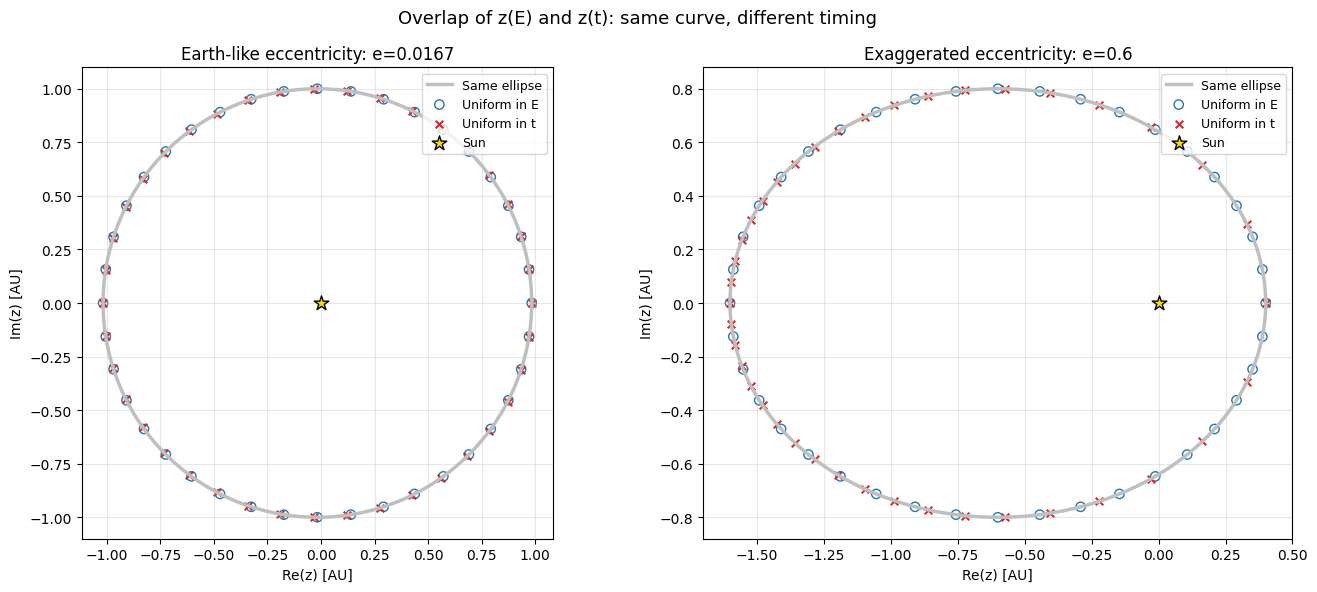

Interpretation:
- The gray curve is the same geometric orbit for both parameterizations.
- Blue circles (uniform E) are parameter-uniform, not time-uniform.
- Red x markers (uniform t) follow physical timing: denser near aphelion, sparser near perihelion.
- For Earth, the effect exists but is subtle because e is small.


In [8]:
# Overlap plot: z(E) vs z(t) on the complex plane
# Same orbit geometry, different pacing along the orbit

def kepler_E_from_M(M, ecc, iters=20):
    E_val = M.copy()
    for _ in range(iters):
        E_val -= (E_val - ecc * np.sin(E_val) - M) / (1 - ecc * np.cos(E_val))
    return E_val


def orbit_samples_for_ecc(ecc, a_val=1.0, n_pts=40, n_curve=2000):
    b_val = a_val * np.sqrt(1 - ecc**2)

    # Reference curve (uniform E)
    E_curve_local = np.linspace(0, 2 * np.pi, n_curve)
    z_curve_local = a_val * (np.cos(E_curve_local) - ecc) + 1j * b_val * np.sin(E_curve_local)

    # Equal-E samples
    E_eq_local = np.linspace(0, 2 * np.pi, n_pts, endpoint=False)
    zE_local = a_val * (np.cos(E_eq_local) - ecc) + 1j * b_val * np.sin(E_eq_local)

    # Equal-time samples (uniform mean anomaly M)
    M_eq_local = np.linspace(0, 2 * np.pi, n_pts, endpoint=False)
    E_t_local = kepler_E_from_M(M_eq_local, ecc)
    zt_local = a_val * (np.cos(E_t_local) - ecc) + 1j * b_val * np.sin(E_t_local)

    return z_curve_local, zE_local, zt_local


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Case A: Earth eccentricity (small difference)
z_curve_A, zE_A, zt_A = orbit_samples_for_ecc(ecc=e, a_val=1.0, n_pts=40)
axes[0].plot(z_curve_A.real, z_curve_A.imag, color="0.75", lw=2.5, label="Same ellipse")
axes[0].scatter(zE_A.real, zE_A.imag, s=45, marker="o", facecolor="none", edgecolor="tab:blue", label="Uniform in E")
axes[0].scatter(zt_A.real, zt_A.imag, s=30, marker="x", color="tab:red", label="Uniform in t")
axes[0].scatter([0], [0], color="gold", edgecolor="black", s=120, marker="*", zorder=5, label="Sun")
axes[0].set_title(f"Earth-like eccentricity: e={e:.4f}")
axes[0].set_xlabel("Re(z) [AU]")
axes[0].set_ylabel("Im(z) [AU]")
axes[0].set_aspect("equal", adjustable="box")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="upper right", fontsize=9)

# Case B: Exaggerated eccentricity (difference becomes obvious)
e_demo = 0.6
z_curve_B, zE_B, zt_B = orbit_samples_for_ecc(ecc=e_demo, a_val=1.0, n_pts=40)
axes[1].plot(z_curve_B.real, z_curve_B.imag, color="0.75", lw=2.5, label="Same ellipse")
axes[1].scatter(zE_B.real, zE_B.imag, s=45, marker="o", facecolor="none", edgecolor="tab:blue", label="Uniform in E")
axes[1].scatter(zt_B.real, zt_B.imag, s=30, marker="x", color="tab:red", label="Uniform in t")
axes[1].scatter([0], [0], color="gold", edgecolor="black", s=120, marker="*", zorder=5, label="Sun")
axes[1].set_title(f"Exaggerated eccentricity: e={e_demo:.1f}")
axes[1].set_xlabel("Re(z) [AU]")
axes[1].set_ylabel("Im(z) [AU]")
axes[1].set_aspect("equal", adjustable="box")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="upper right", fontsize=9)

plt.suptitle("Overlap of z(E) and z(t): same curve, different timing", fontsize=13)
plt.tight_layout()
plt.show()

print("Interpretation:")
print("- The gray curve is the same geometric orbit for both parameterizations.")
print("- Blue circles (uniform E) are parameter-uniform, not time-uniform.")
print("- Red x markers (uniform t) follow physical timing: denser near aphelion, sparser near perihelion.")
print("- For Earth, the effect exists but is subtle because e is small.")

## 6. 3D Parameter-Lifted View: $(x,y,E)$ vs $(x,y,t)$

To compare pacing directly, we lift the 2D orbit into 3D:

$$
(E, x(E), y(E)) \quad \text{and} \quad (t, x(t), y(t)).
$$

Both traces project to the same ellipse in the $(x,y)$ plane, but their progression along the parameter axis differs.

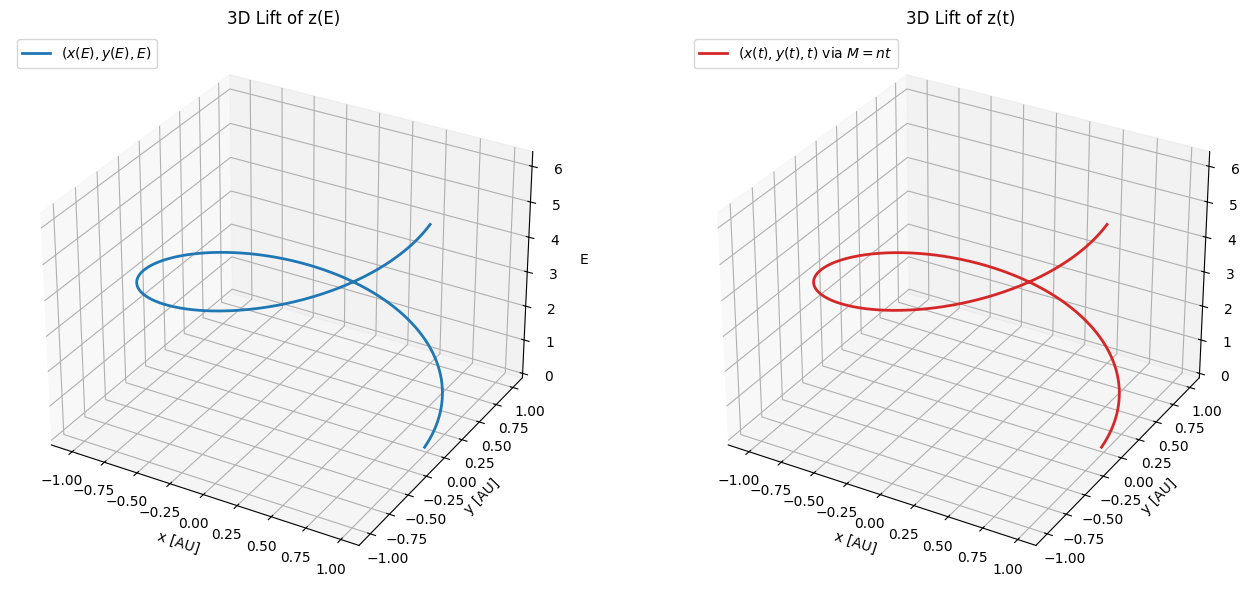

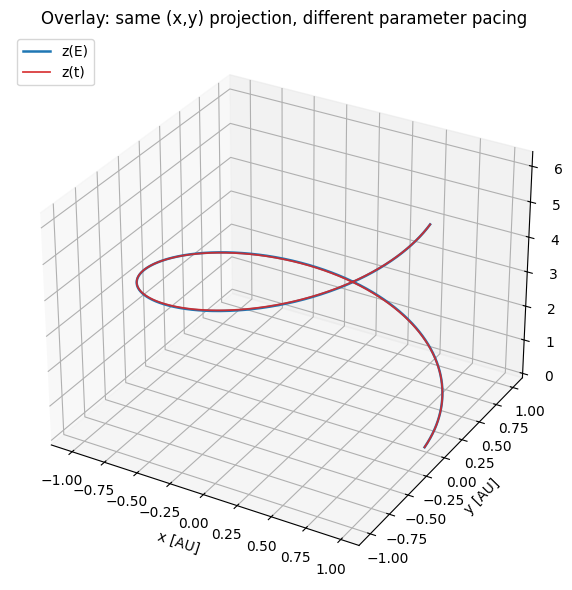

3D interpretation:
- Blue curve uses uniform eccentric anomaly E.
- Red curve uses uniform time (represented by uniform M = nt).
- Their XY projections are the same ellipse, but z-axis progression differs.


In [10]:
# 3D visualization: parameter-lifted curves for z(E) and z(t)
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

N3 = 1200
E3 = np.linspace(0, 2 * np.pi, N3, endpoint=False)

# z(E)
xE3 = a * (np.cos(E3) - e)
yE3 = b * np.sin(E3)

# z(t): use uniform mean anomaly M as time-like parameter over one period
M3 = np.linspace(0, 2 * np.pi, N3, endpoint=False)
E_from_M3 = M3.copy()
for _ in range(20):
    E_from_M3 -= (E_from_M3 - e * np.sin(E_from_M3) - M3) / (1 - e * np.cos(E_from_M3))

xT3 = a * (np.cos(E_from_M3) - e)
yT3 = b * np.sin(E_from_M3)

fig = plt.figure(figsize=(14, 6))

# Left: (x, y, E)
ax1 = fig.add_subplot(121, projection="3d")
ax1.plot(xE3, yE3, E3, color="tab:blue", lw=2, label=r"$(x(E), y(E), E)$")
ax1.set_xlabel("x [AU]")
ax1.set_ylabel("y [AU]")
ax1.set_zlabel("E")
ax1.set_title("3D Lift of z(E)")
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper left")

# Right: (x, y, t~M)
ax2 = fig.add_subplot(122, projection="3d")
ax2.plot(xT3, yT3, M3, color="tab:red", lw=2, label=r"$(x(t), y(t), t)$ via $M=nt$")
ax2.set_xlabel("x [AU]")
ax2.set_ylabel("y [AU]")
ax2.set_zlabel("t (scaled as M)")
ax2.set_title("3D Lift of z(t)")
ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()

# Optional overlay in one 3D axis to compare directly
fig2 = plt.figure(figsize=(8, 6))
ax = fig2.add_subplot(111, projection="3d")
ax.plot(xE3, yE3, E3, color="tab:blue", lw=1.8, label="z(E)")
ax.plot(xT3, yT3, M3, color="tab:red", lw=1.3, alpha=0.9, label="z(t)")
ax.set_xlabel("x [AU]")
ax.set_ylabel("y [AU]")
ax.set_zlabel("parameter")
ax.set_title("Overlay: same (x,y) projection, different parameter pacing")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

print("3D interpretation:")
print("- Blue curve uses uniform eccentric anomaly E.")
print("- Red curve uses uniform time (represented by uniform M = nt).")
print("- Their XY projections are the same ellipse, but z-axis progression differs.")